# Radial temperature profile

In [1]:
%matplotlib widget

import pandas as pd
import scipy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.constants as sc
from matplotlib.ticker import MultipleLocator

/home/pallab/Softwares/anaconda3/envs/MDAna/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Analysis

In [2]:
def FormatPlot(ax):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.xaxis.set_tick_params(width=2,length=8,direction='in',labelsize=14)
    ax.yaxis.set_tick_params(width=2,length=8,direction='in',labelsize=14)
    ax.xaxis.set_tick_params(which='minor',width=2,length=4,direction='in')
    ax.yaxis.set_tick_params(which='minor',width=2,length=4,direction='in')
    
    ax.grid(which='major',color='silver',linestyle='dashed')
    ax.grid(which='minor',color='silver',linestyle='dotted',alpha=0.5)

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define Z(R) here ---
def Z_of_R(R, center, edge, t):
    return -(center - edge) * np.exp(-t * R) + edge

# For general radial function: dZ/dR
def dZ_dR_func(R, center, edge, t):
    return (center - edge) * t * np.exp(-t * R)

def PLOT_2D_Profile(center_value, edge_value, t, CMAP='coolwarm'):
    # Parameters
    N = 400
    CMAP = 'coolwarm'
    if center_value*edge_value==1:
        cmap = CMAP
    else:
        cmap = f"{CMAP}_r"
    # Grid
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    R /= R.max()
    Z = Z_of_R(R, center_value, edge_value, t)
    dZ_dR = dZ_dR_func(R, center_value, edge_value, t)
    
    # Avoid division by zero at center
    with np.errstate(divide='ignore', invalid='ignore'):
        U = dZ_dR * (X)# / R)
        V = dZ_dR * (Y)# / R)
    
    # Plot
    fig, ax = plt.subplots(figsize=(4,4),dpi=100)
    
    # Filled contour
    ax.contourf(X, Y, Z, levels=200, cmap=cmap)
    
    # Vector field (arrows at bin centers)
    step = 50
    ax.quiver(X[step:,step:][::step, ::step], Y[step:,step:][::step, ::step],
              U[step:,step:][::step, ::step], V[step:,step:][::step, ::step],
              color="k", scale=5, width=0.012, pivot="mid")
    
    # Clean schematic style
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    ax.set_aspect("equal")
    
    #plt.show()
    plt.tight_layout()
    #plt.savefig(args[4])
    #plt.show()

# Figures

## v-Rescale thermostat

In [15]:
import numpy as np
from scipy.stats import gaussian_kde

XDm = np.array([4,8,12,16,20]*2)
DD_p310s220 = np.load('Teff_p310s220_profile_vRescale.npy')
DD_p220s310 = np.load('Teff_p220s310_profile_vRescale.npy')
DDm_p310s220 = DD_p310s220.mean(axis=1)
DDm_p220s310 = DD_p220s310.mean(axis=1)

DDm_p310s220 = DDm_p310s220 - 220
DDm_p220s310 = - DDm_p220s310 + 310

DDm = np.hstack((DDm_p310s220,DDm_p220s310))

def monoExp(x, m, t):
    return m * np.exp(-t * x) + 0

p0 = (2000, .1)
params, cv = scipy.optimize.curve_fit(monoExp, XDm, DDm, p0)
m, t = params

print(\
f"""
Thermostat: v-Rescale

Equation:
    T_bulk +/- m * exp(-t * r)

The parameters are:
    m: {round(m,2)}
    t: {round(t,2)}
"""
)


Thermostat: v-Rescale

Equation:
    T_bulk +/- m * exp(-t * r)

The parameters are:
    m: 24.31
    t: 0.24



## Fig S5A

(5, 1001)


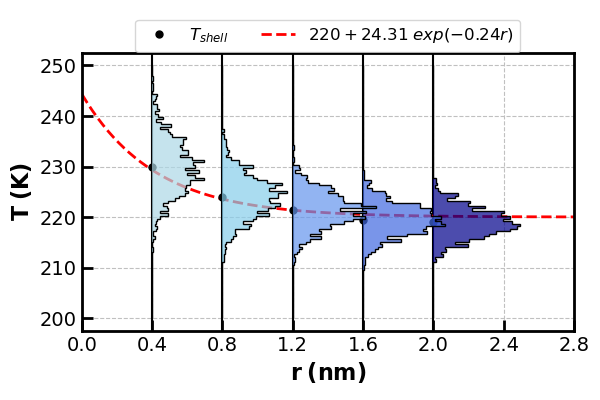

In [4]:
# Fig 2A

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
import numpy as np
from scipy.stats import gaussian_kde

XDm = np.array([4,8,12,16,20])
DD = np.load('Teff_p310s220_profile_vRescale.npy')

print(DD.shape)
DDm = DD.mean(axis=1)

X = np.linspace(0,30,100)
def monoExp(x, m, t):
    return m * np.exp(-t * x) + 220

p0 = (2000, .1)
params, cv = scipy.optimize.curve_fit(monoExp, XDm, DDm, p0)
m, t = params

m = 24.31
t = 0.24

# Generate data for normal distributions
T = np.linspace(200,250,100)
x = np.linspace(0, 16, 1000)
bins = np.linspace(200, 250, 100, endpoint=True)

plt.figure(figsize=(6,4))

# Add gridlines
plt.axvline(x=4, color='k', linestyle='-')
plt.axvline(x=8, color='k', linestyle='-')
plt.axvline(x=12, color='k', linestyle='-')
plt.axvline(x=16, color='k', linestyle='-')
plt.axvline(x=20, color='k', linestyle='-')

ax1 = plt.gca()
ax1.set_xlim(0,28)

ax2 = ax1.twiny()
ax2.grid(False)
ax2.set_xlim(0,0.84)

ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='stepfilled', color='darkblue',alpha=0.7)
ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='step', color='k')
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='stepfilled', color='royalblue',alpha=0.7)
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='step', color='k')
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='stepfilled',color='cornflowerblue',alpha=0.7)
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='step', color='k')
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='stepfilled',color='skyblue',alpha=0.7)
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='step', color='k')
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='stepfilled',color='lightblue',alpha=0.7)
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='step', color='k')

ax1.plot(XDm,DDm,'o',label=r'$T_{shell}$',color='k',markersize=5,zorder=200)

# Add labels and legend
ax2.xaxis.set_major_locator(NullLocator())
#ax2.set_xlabel('Probability')
ax1.set_xlabel(r'$\bf{r\;(nm)}$',fontsize=16)
ax1.set_ylabel(r'$\bf{T\;(K)}$',fontsize=16)
#plt.title('Normal Distributions with Means at Different Y-values')
#plt.legend()

from sklearn.metrics import r2_score
y_observed = DDm
y_predicted = monoExp(XDm, m, t)
r_squared = r2_score(y_observed, y_predicted)
S = r"$220 + %.2f\;exp(-%.2fr)$"%(m,t)

ax1.plot(X, monoExp(X, m, t),'--',color='red',label=S, lw=2)
ax1.xaxis.set_major_locator(MultipleLocator(4))

def modified_label(x, pos):
    """The function to be used for formatting the tick labels."""
    return f'{x * 0.1:.1f}' # .1f formats the number to one decimal place

# --- 4. Apply the formatter to the x-axis ---
# Create a FuncFormatter using the function
formatter = ticker.FuncFormatter(modified_label)

# Set the formatter for the x-axis
ax1.xaxis.set_major_formatter(formatter)

# Show plot
#plt.grid(True)
#plt.title(S)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncol=2,fontsize=12)

plt.tight_layout()

FormatPlot(ax1)
plt.show()
plt.tight_layout()
#plt.savefig('p310s220_hyd_Temp_fit1.png',dpi=300)

## Fig S5C

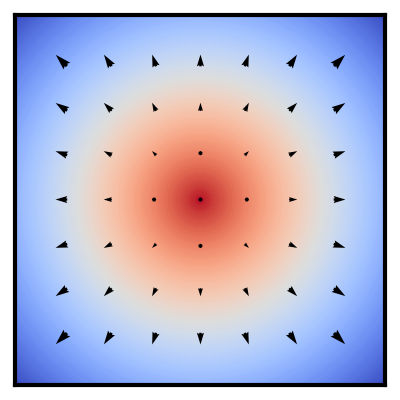

In [28]:
# system: p310s220

# temperature at center: 310K
# temperature at bulk: 220K
# scaled temperature from center to box-edge: 1 to 0 (scaled for a schematic representation)
# rate of decay, t = 0.24

PLOT_2D_Profile(1,0,t=0.24)

## Fig S5B

(5, 1001)


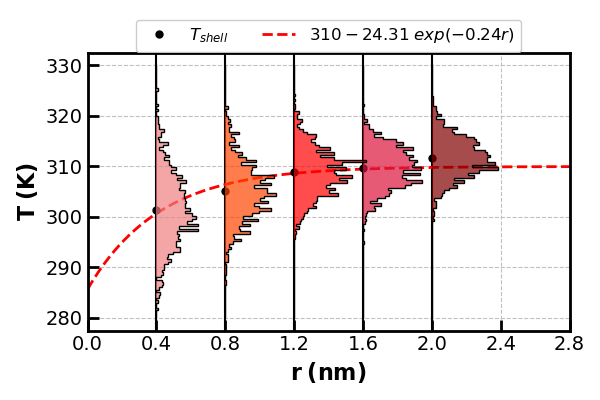

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
import numpy as np
from scipy.stats import gaussian_kde

XDm = np.array([4,8,12,16,20])
DD = np.load('Teff_p220s310_profile_vRescale.npy')

print(DD.shape)
DDm = DD.mean(axis=1)

X = np.linspace(0,30,100)
def monoExp(x, m, t):
    return m * np.exp(-t * x) + 310

p0 = (2000, .1)
params, cv = scipy.optimize.curve_fit(monoExp, XDm, DDm, p0)
m, t = params
m = -24.31
t = 0.24
#S = r"$%.2f\;exp(-%.2fd)+T_{S},\;T_{S}=310K$"%(m,t)

# Generate data for normal distributions
T = np.linspace(280,330,100)
x = np.linspace(0, 16, 1000)
bins = np.linspace(280, 330, 100, endpoint=True)

plt.figure(figsize=(6,4))

# Add gridlines
plt.axvline(x=4, color='k', linestyle='-')
plt.axvline(x=8, color='k', linestyle='-')
plt.axvline(x=12, color='k', linestyle='-')
plt.axvline(x=16, color='k', linestyle='-')
plt.axvline(x=20, color='k', linestyle='-')

ax1 = plt.gca()
ax1.set_xlim(0,28)

ax2 = ax1.twiny()
ax2.grid(False)
ax2.set_xlim(0,0.84)

ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='stepfilled', color='maroon',alpha=0.7)
ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='step', color='k')
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='stepfilled', color='crimson',alpha=0.7)
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='step', color='k')
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='stepfilled',color='red',alpha=0.7)
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='step', color='k')
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='stepfilled',color='orangered',alpha=0.7)
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='step', color='k')
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='stepfilled',color='lightcoral',alpha=0.7)
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='step', color='k')

ax1.plot(XDm,DDm,'o',label=r'$T_{shell}$',color='k',markersize=5,zorder=200)

# Add labels and legend
ax2.xaxis.set_major_locator(NullLocator())
#ax2.set_xlabel('Probability')
ax1.set_xlabel(r'$\bf{r\;(nm)}$', fontsize=16)
ax1.set_ylabel(r'$\bf{T\;(K)}$', fontsize=16)
#plt.title('Normal Distributions with Means at Different Y-values')
#plt.legend()

from sklearn.metrics import r2_score
y_observed = DDm
y_predicted = monoExp(XDm, m, t)
r_squared = r2_score(y_observed, y_predicted)
S = r"$310 %.2f\;exp(-%.2fr)$"%(m,t)

ax1.plot(X, monoExp(X, m, t), '--', color='r', label=S, lw=2)
ax1.xaxis.set_major_locator(MultipleLocator(4))

def modified_label(x, pos):
    """The function to be used for formatting the tick labels."""
    return f'{x * 0.1:.1f}' # .1f formats the number to one decimal place

# --- 4. Apply the formatter to the x-axis ---
# Create a FuncFormatter using the function
formatter = ticker.FuncFormatter(modified_label)

# Set the formatter for the x-axis
ax1.xaxis.set_major_formatter(formatter)

FormatPlot(ax1)

# Show plot
#plt.grid(True)
leg = ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncol=2,fontsize=12,framealpha=1,fancybox=True)
leg.set_zorder(10)
plt.tight_layout()
plt.show()
#plt.savefig('p220s310_hyd_Temp_fit_3param1.png',dpi=300)

## Fig S5D

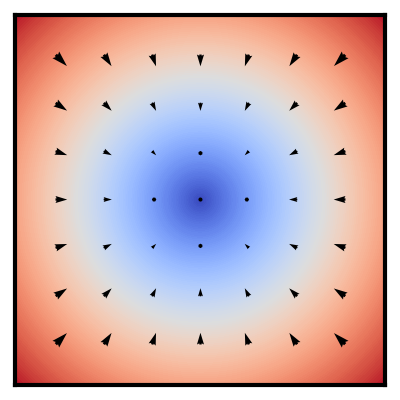

In [27]:
# system: p220s310

# temperature at center: 220K
# temperature at bulk: 310K
# scaled temperature from center to box-edge: 0 to 1 (scaled for a schematic representation)
# rate of decay, t = 0.24

PLOT_2D_Profile(0,1,t=0.24)

## Nose-Hoover thermostat

In [16]:
import numpy as np
from scipy.stats import gaussian_kde

XDm = np.array([4,8,12,16,20]*2)
DD_p310s220 = np.load('Teff_p310s220_profile_NoseHoover.npy')
DD_p220s310 = np.load('Teff_p220s310_profile_NoseHoover.npy')
DDm_p310s220 = DD_p310s220.mean(axis=1)
DDm_p220s310 = DD_p220s310.mean(axis=1)

DDm_p310s220 = DDm_p310s220 - 220
DDm_p220s310 = - DDm_p220s310 + 310

DDm = np.hstack((DDm_p310s220,DDm_p220s310))

def monoExp(x, m, t):
    return m * np.exp(-t * x) + 0

p0 = (2000, .1)
params, cv = scipy.optimize.curve_fit(monoExp, XDm, DDm, p0)
m, t = params

print(\
f"""
Thermostat: v-Rescale

Equation:
    T_bulk +/- m * exp(-t * r)

The parameters are:
    m: {round(m,2)}
    t: {round(t,2)}
"""
)


Thermostat: v-Rescale

Equation:
    T_bulk +/- m * exp(-t * r)

The parameters are:
    m: 26.34
    t: 0.19



## Fig 2A

(5, 1001)


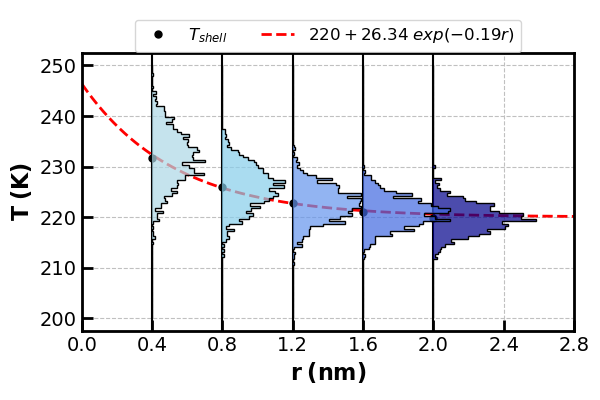

In [17]:
# Fig 2A

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
import numpy as np
from scipy.stats import gaussian_kde

XDm = np.array([4,8,12,16,20])
DD = np.load('Teff_p310s220_profile_NoseHoover.npy')
print(DD.shape)
DDm = DD.mean(axis=1)

X = np.linspace(0,30,100)
def monoExp(x, m, t):
    return m * np.exp(-t * x) + 220

p0 = (2000, .1)
params, cv = scipy.optimize.curve_fit(monoExp, XDm, DDm, p0)
m, t = params
#S = r"$%.2f\;exp(-%.2fd)+T_{S},\;T_{S}=220K$"%(m,t)

m = 26.34
t = 0.19

# Generate data for normal distributions
T = np.linspace(200,250,100)
x = np.linspace(0, 16, 1000)
bins = np.linspace(200, 250, 100, endpoint=True)

plt.figure(figsize=(6,4))

# Add gridlines
plt.axvline(x=4, color='k', linestyle='-')
plt.axvline(x=8, color='k', linestyle='-')
plt.axvline(x=12, color='k', linestyle='-')
plt.axvline(x=16, color='k', linestyle='-')
plt.axvline(x=20, color='k', linestyle='-')

ax1 = plt.gca()
ax1.set_xlim(0,28)

ax2 = ax1.twiny()
ax2.grid(False)
ax2.set_xlim(0,0.84)

ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='stepfilled', color='darkblue',alpha=0.7)
ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='step', color='k')
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='stepfilled', color='royalblue',alpha=0.7)
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='step', color='k')
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='stepfilled',color='cornflowerblue',alpha=0.7)
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='step', color='k')
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='stepfilled',color='skyblue',alpha=0.7)
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='step', color='k')
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='stepfilled',color='lightblue',alpha=0.7)
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='step', color='k')

ax1.plot(XDm,DDm,'o',label=r'$T_{shell}$',color='k',markersize=5,zorder=200)

# Add labels and legend
ax2.xaxis.set_major_locator(NullLocator())
#ax2.set_xlabel('Probability')
ax1.set_xlabel(r'$\bf{r\;(nm)}$',fontsize=16)
ax1.set_ylabel(r'$\bf{T\;(K)}$',fontsize=16)
#plt.title('Normal Distributions with Means at Different Y-values')
#plt.legend()

from sklearn.metrics import r2_score
y_observed = DDm
y_predicted = monoExp(XDm, m, t)
r_squared = r2_score(y_observed, y_predicted)
S = r"$220 + %.2f\;exp(-%.2fr)$"%(m,t)

ax1.plot(X, monoExp(X, m, t),'--',color='red',label=S, lw=2)
ax1.xaxis.set_major_locator(MultipleLocator(4))

def modified_label(x, pos):
    """The function to be used for formatting the tick labels."""
    return f'{x * 0.1:.1f}' # .1f formats the number to one decimal place

# --- 4. Apply the formatter to the x-axis ---
# Create a FuncFormatter using the function
formatter = ticker.FuncFormatter(modified_label)

# Set the formatter for the x-axis
ax1.xaxis.set_major_formatter(formatter)

# Show plot
#plt.grid(True)
#plt.title(S)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncol=2,fontsize=12)

plt.tight_layout()

FormatPlot(ax1)
plt.show()
plt.tight_layout()
#plt.savefig('p310s220_hyd_Temp_fit_2.png',dpi=300)

## Fig 2C

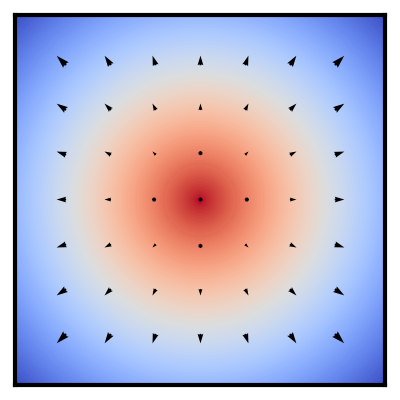

In [29]:
# system: p310s220

# temperature at center: 310K
# temperature at bulk: 220K
# scaled temperature from center to box-edge: 1 to 0 (scaled for a schematic representation)
# rate of decay, t = 0.19

PLOT_2D_Profile(1,0,t=0.19)

## Fig 2B

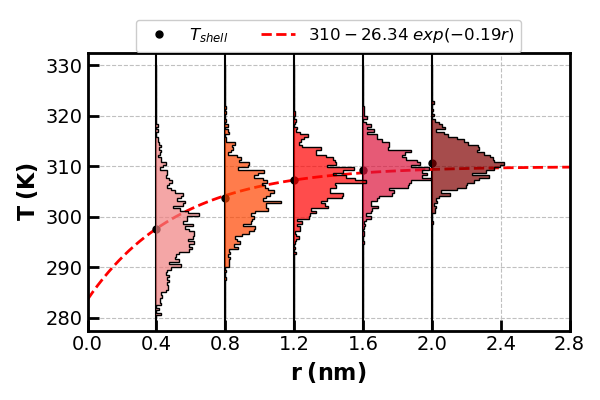

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
import numpy as np
from scipy.stats import gaussian_kde

XDm = np.array([4,8,12,16,20])
DD = np.load('Teff_p220s310_profile_NoseHoover.npy')
DDm = DD.mean(axis=1)

X = np.linspace(0,30,100)
def monoExp(x, m, t):
    return m * np.exp(-t * x) + 310

p0 = (2000, .1)
params, cv = scipy.optimize.curve_fit(monoExp, XDm, DDm, p0)
m, t = params
m = -26.34
t = 0.19
#S = r"$%.2f\;exp(-%.2fd)+T_{S},\;T_{S}=310K$"%(m,t)

# Generate data for normal distributions
T = np.linspace(280,330,100)
x = np.linspace(0, 16, 1000)
bins = np.linspace(280, 330, 100, endpoint=True)

plt.figure(figsize=(6,4))

# Add gridlines
plt.axvline(x=4, color='k', linestyle='-')
plt.axvline(x=8, color='k', linestyle='-')
plt.axvline(x=12, color='k', linestyle='-')
plt.axvline(x=16, color='k', linestyle='-')
plt.axvline(x=20, color='k', linestyle='-')

ax1 = plt.gca()
ax1.set_xlim(0,28)

ax2 = ax1.twiny()
ax2.grid(False)
ax2.set_xlim(0,0.84)

ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='stepfilled', color='maroon',alpha=0.7)
ax2.hist(DD[4], bins, density=True, orientation='horizontal', bottom=0.60, histtype='step', color='k')
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='stepfilled', color='crimson',alpha=0.7)
ax2.hist(DD[3], bins, density=True, orientation='horizontal', bottom=0.48, histtype='step', color='k')
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='stepfilled',color='red',alpha=0.7)
ax2.hist(DD[2], bins, density=True, orientation='horizontal', bottom=0.36, histtype='step', color='k')
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='stepfilled',color='orangered',alpha=0.7)
ax2.hist(DD[1], bins, density=True, orientation='horizontal', bottom=0.24, histtype='step', color='k')
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='stepfilled',color='lightcoral',alpha=0.7)
ax2.hist(DD[0], bins, density=True, orientation='horizontal', bottom=0.12, histtype='step', color='k')

ax1.plot(XDm,DDm,'o',label=r'$T_{shell}$',color='k',markersize=5,zorder=200)

# Add labels and legend
ax2.xaxis.set_major_locator(NullLocator())
#ax2.set_xlabel('Probability')
ax1.set_xlabel(r'$\bf{r\;(nm)}$', fontsize=16)
ax1.set_ylabel(r'$\bf{T\;(K)}$', fontsize=16)
#plt.title('Normal Distributions with Means at Different Y-values')
#plt.legend()

from sklearn.metrics import r2_score
y_observed = DDm
y_predicted = monoExp(XDm, m, t)
r_squared = r2_score(y_observed, y_predicted)
S = r"$310 %.2f\;exp(-%.2fr)$"%(m,t)

ax1.plot(X, monoExp(X, m, t), '--', color='r', label=S, lw=2)
ax1.xaxis.set_major_locator(MultipleLocator(4))

def modified_label(x, pos):
    """The function to be used for formatting the tick labels."""
    return f'{x * 0.1:.1f}' # .1f formats the number to one decimal place

# --- 4. Apply the formatter to the x-axis ---
# Create a FuncFormatter using the function
formatter = ticker.FuncFormatter(modified_label)

# Set the formatter for the x-axis
ax1.xaxis.set_major_formatter(formatter)

FormatPlot(ax1)

# Show plot
#plt.grid(True)
leg = ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),ncol=2,fontsize=12,framealpha=1,fancybox=True)
leg.set_zorder(10)
plt.tight_layout()
plt.show()
#plt.savefig('p220s310_hyd_Temp_fit_3param_2.png',dpi=300)

## Fig 2D

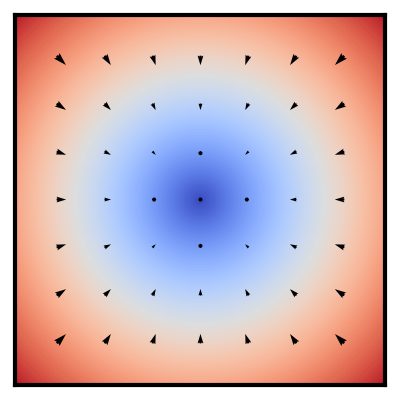

In [30]:
# system: p220s310

# temperature at center: 220K
# temperature at bulk: 310K
# scaled temperature from center to box-edge: 0 to 1 (scaled for a schematic representation)
# rate of decay, t = 0.19

PLOT_2D_Profile(0,1,t=0.19)